In [25]:
import os
import sys

while not os.path.isdir("src"):
    parent = os.path.dirname(os.getcwd())

    if parent == os.getcwd():
        break

    os.chdir(parent)

sys.path.insert(0, "src")

In [26]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_pooled_dataset, build_pooled_sequences

from tradinglab.models import LSTMRegressor, MLP
from tradinglab.ml import train_model, predict

from tradinglab.simulator import PortfolioSimulator
from tradinglab.strategies.predictor import model_to_strategy

In [27]:
torch.manual_seed(0)
np.random.seed(0)

EPOCHS = 150
SEQ_LEN = 10
TOP_K = 4
START_CAPITAL = 1000.0

In [ ]:
feed = DataFeed.from_dir("data/egx")

split_day = int(feed.n_days * 0.7)

X_train, y_train, X_test, y_test = build_pooled_dataset(
    feed,
    split_day
)

n_features = X_train.shape[1]

print("train:", X_train.shape)
print("test :", X_test.shape)
print("n_features:", n_features)

train: (26588, 5)
test : (11798, 5)
n_features: 5


/Users/sandra/2026-orion/src/tradinglab/features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


In [29]:
def to_sequences(X, y, seq_len=5):
    xs = []
    ys = []

    for i in range(seq_len, len(X)):
        xs.append(X[i-seq_len:i])
        ys.append(y[i])

    return (
        np.array(xs, dtype="float32"),
        np.array(ys, dtype="float32")
    )

In [30]:

X_train_seq, y_train_seq = to_sequences(
    X_train,
    y_train,
    seq_len=SEQ_LEN
)

X_test_seq, y_test_seq = to_sequences(
    X_test,
    y_test,
    seq_len=SEQ_LEN
)

print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)

print("X_test_seq :", X_test_seq.shape)
print("y_test_seq :", y_test_seq.shape)

X_train_seq: (26578, 10, 5)
y_train_seq: (26578,)
X_test_seq : (11788, 10, 5)
y_test_seq : (11788,)


In [31]:
assert X_train_seq.shape[1:] == (
    SEQ_LEN,
    n_features
)

print("to_sequences correct ✓")

to_sequences correct ✓


In [32]:
lstm = LSTMRegressor(
    n_features=n_features,
    hidden=32
)

history = train_model(
    lstm,
    X_train_seq,
    y_train_seq,
    X_test_seq,
    y_test_seq,
    epochs=EPOCHS
)

In [33]:
import torch
import matplotlib.pyplot as plt

from tradinglab.models import LSTMRegressor
from tradinglab.ml import train_model

torch.manual_seed(0)

lstm = LSTMRegressor(
    n_features=n_features,
    hidden=64
)

history = train_model(
    lstm,
    X_train_seq,
    y_train_seq,
    X_test_seq,
    y_test_seq,
    epochs=300
)

print("LSTM final train loss:", history["train"][-1])
print("LSTM final test loss :", history["test"][-1])

LSTM final train loss: 0.0009506644564680755
LSTM final test loss : 0.0005785273388028145


In [ ]:
print(
    f"final train loss: {history['train'][-1]:.5f}"
)

print(
    f"final test loss : {history['test'][-1]:.5f}"
)

final train loss: 0.00095
final test loss : 0.00058


In [ ]:
def lstm_to_strategy(model, seq_len, top_k=2):

    def strategy(observation):

        window = observation[:, -seq_len:, :]

        predictions = predict(
            model,
            window.astype("float32")
        )

        from tradinglab.strategies.predictor import predictions_to_weights

        return predictions_to_weights(
            predictions,
            top_k
        )

    return strategy

In [36]:
with torch.no_grad():
    lstm_predictions = predict(
        lstm,
        X_test_seq.astype("float32")
    )

print("Predictions shape:", lstm_predictions.shape)
print("Actual shape:", y_test_seq.shape)

Predictions shape: (11788,)
Actual shape: (11788,)


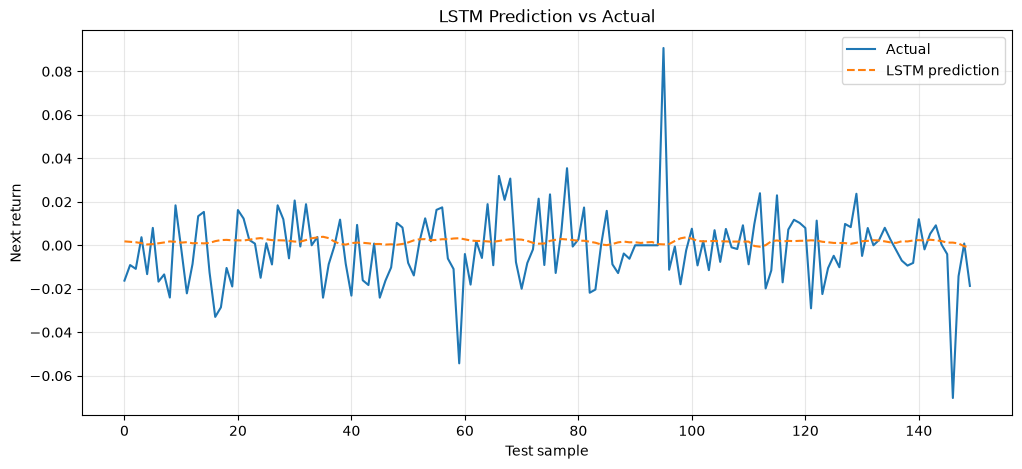

In [37]:
show_n = min(150, len(y_test_seq))

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_seq[:show_n],
    label="Actual"
)

plt.plot(
    lstm_predictions[:show_n],
    label="LSTM prediction",
    linestyle="--"
)

plt.legend()
plt.grid(alpha=0.3)
plt.title("LSTM Prediction vs Actual")
plt.xlabel("Test sample")
plt.ylabel("Next return")

plt.show()

In [38]:
lstm = LSTMRegressor(
    n_features=n_features,
    hidden=32
)

history = train_model(
    lstm,
    X_train_seq,
    y_train_seq,
    X_test_seq,
    y_test_seq,
    epochs=EPOCHS
)

print("LSTM final train loss:", history["train"][-1])
print("LSTM final test loss :", history["test"][-1])

LSTM final train loss: 0.000951006542891264
LSTM final test loss : 0.0005782110965810716


In [39]:
lstm.eval()

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
)

with torch.no_grad():
    lstm_predictions = lstm(X_test_tensor).cpu().numpy().reshape(-1)

actual = np.asarray(y_test_seq).reshape(-1)

print("========== LSTM PREDICTION CHECK ==========")
print(f"Mean actual     : {actual.mean():.6f}")
print(f"Mean prediction : {lstm_predictions.mean():.6f}")
print(f"Min prediction  : {lstm_predictions.min():.6f}")
print(f"Max prediction  : {lstm_predictions.max():.6f}")

print()
print("Positive predictions:", np.sum(lstm_predictions > 0))
print("Negative predictions:", np.sum(lstm_predictions < 0))

========== LSTM PREDICTION CHECK ==========
Mean actual     : 0.001343
Mean prediction : 0.001929
Min prediction  : -0.000678
Max prediction  : 0.007408

Positive predictions: 11782
Negative predictions: 6


In [40]:
def lstm_to_strategy_ranked(model, seq_len=10, top_k=4):

    def strategy(obs):
        # obs shape: (n_assets, lookback, n_features)
        window = obs[:, -seq_len:, :]

        x = torch.tensor(
            window,
            dtype=torch.float32
        )

        model.eval()

        with torch.no_grad():
            predictions = model(x).cpu().numpy().reshape(-1)

        # Select the stocks with the highest predicted returns
        top_indices = np.argsort(predictions)[-top_k:]

        weights = np.zeros(len(predictions))
        weights[top_indices] = 1.0 / top_k

        return weights

    return strategy

In [41]:
import os

print("Current directory:", os.getcwd())
print("data exists:", os.path.exists("data"))
print("egx exists:", os.path.exists("data/egx"))

if os.path.exists("data/egx"):
    print("Files:", os.listdir("data/egx")[:10])

Current directory: /Users/sandra/2026-orion
data exists: True
egx exists: True
Files: ['ALCN.csv', 'MCQE.csv', 'SUGR.csv', 'RMDA.csv', 'EFID.csv', 'ABUK.csv', 'ISPH.csv', 'EGAL.csv', 'SWDY.csv', 'ORAS.csv']


In [42]:
import os

os.chdir("/Users/sandra/2026-orion")

print("Current directory:", os.getcwd())
print("data exists:", os.path.exists("data"))
print("egx exists:", os.path.exists("data/egx"))

Current directory: /Users/sandra/2026-orion
data exists: True
egx exists: True


In [43]:
from tradinglab.data_feed import DataFeed

feed = DataFeed.from_dir("data/egx")

print("feed.n_assets:", feed.n_assets)
print("feed.n_days:", feed.n_days)

feed.n_assets: 34
feed.n_days: 1159


In [44]:
from tradinglab.backtester import run_backtest
from tradinglab.simulator import PortfolioSimulator

sim = PortfolioSimulator(feed)

split = int(feed.n_days * 0.7)

In [ ]:
def lstm_to_strategy_ranked(model, seq_len=10, top_k=4):

    def strategy(obs):
        window = obs[:, -seq_len:, :]

        x = torch.tensor(
            window,
            dtype=torch.float32
        )

        model.eval()

        with torch.no_grad():
            predictions = model(x).cpu().numpy().reshape(-1)

        top_indices = np.argsort(predictions)[-top_k:]

        weights = np.zeros(len(predictions))
        weights[top_indices] = 1.0 / top_k

        return weights

    return strategy

In [46]:
n_features = 5

print("n_features:", n_features)

n_features: 5


In [47]:
print("X_train_seq exists:", "X_train_seq" in globals())
print("y_train_seq exists:", "y_train_seq" in globals())
print("X_test_seq exists :", "X_test_seq" in globals())
print("y_test_seq exists :", "y_test_seq" in globals())

X_train_seq exists: True
y_train_seq exists: True
X_test_seq exists : True
y_test_seq exists : True


In [48]:
print("X_train exists:", "X_train" in globals())
print("y_train exists:", "y_train" in globals())
print("X_test exists :", "X_test" in globals())
print("y_test exists :", "y_test" in globals())

print("SEQ_LEN exists:", "SEQ_LEN" in globals())

X_train exists: True
y_train exists: True
X_test exists : True
y_test exists : True
SEQ_LEN exists: True


In [49]:
import torch

from tradinglab.models import LSTMRegressor
from tradinglab.ml import train_model

torch.manual_seed(0)

lstm = LSTMRegressor(
    n_features=n_features,
    hidden=32
)

history = train_model(
    lstm,
    X_train_seq,
    y_train_seq,
    X_test_seq,
    y_test_seq,
    epochs=1500
)

print("LSTM final train loss:", history["train"][-1])
print("LSTM final test loss :", history["test"][-1])

LSTM final train loss: 0.0009466299670748413
LSTM final test loss : 0.0005804651882499456


In [50]:
result_lstm_ranked = run_backtest(
    sim,
    lstm_to_strategy_ranked(
        lstm,
        seq_len=SEQ_LEN,
        top_k=TOP_K
    ),
    lookback=30,
    start=split
)

print("Ranked LSTM backtest completed!")
print("Portfolio days:", len(result_lstm_ranked["portfolio"]))

/Users/sandra/2026-orion/src/tradinglab/features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


Ranked LSTM backtest completed!
Portfolio days: 347


In [51]:
lstm_mse = np.mean(
    (y_test_seq - lstm_predictions) ** 2
)

lstm_rmse = np.sqrt(lstm_mse)

print(f"LSTM MSE  : {lstm_mse:.6f}")
print(f"LSTM RMSE : {lstm_rmse:.6f}")

LSTM MSE  : 0.000578
LSTM RMSE : 0.024046


In [52]:
print("LSTM training summary")
print("---------------------")
print(f"Sequence length : {SEQ_LEN}")
print(f"Hidden size     : 32")
print(f"Epochs          : {EPOCHS}")
print(f"Features        : {n_features}")
print(f"Train loss      : {history['train'][-1]:.5f}")
print(f"Test loss       : {history['test'][-1]:.5f}")
print(f"Test RMSE       : {lstm_rmse:.5f}")

LSTM training summary
---------------------
Sequence length : 10
Hidden size     : 32
Epochs          : 150
Features        : 5
Train loss      : 0.00095
Test loss       : 0.00058
Test RMSE       : 0.02405


In [53]:
def lstm_strategy_from_observation(
    model,
    observation,
    seq_len=10,
    top_k=4
):
    window = observation[:, -seq_len:, :]

    predictions = predict(
        model,
        window.astype("float32")
    )

    from tradinglab.strategies.predictor import predictions_to_weights

    weights = predictions_to_weights(
        predictions,
        top_k
    )

    return weights

In [54]:
lookback = 30

test_day = split

observation = feed.close[
    test_day - lookback:test_day
]

print("Raw observation shape:", observation.shape)

Raw observation shape: (30, 34)


In [55]:
from tradinglab.observation import build_observation

observation = build_observation(
    feed,
    test_day,
    lookback
)

print("Observation shape:", observation.shape)

Observation shape: (34, 30, 5)


In [56]:
window = observation[:, -SEQ_LEN:, :]

print("Full observation :", observation.shape)
print("LSTM window      :", window.shape)
print("Expected         :", (feed.n_assets, SEQ_LEN, n_features))

Full observation : (34, 30, 5)
LSTM window      : (34, 10, 5)
Expected         : (34, 10, 5)


In [57]:
test_predictions = predict(
    lstm,
    window.astype("float32")
)

print("Predictions:", test_predictions)
print("Predictions shape:", test_predictions.shape)

Predictions: [ 0.00213245  0.00188742  0.00346962  0.00236462  0.0002568   0.00197465
  0.0022293   0.00484303  0.00158246  0.00045911  0.00188828  0.00186221
  0.0013014   0.00355236  0.00391553  0.00396439  0.00188033  0.00146025
  0.00093169  0.00321707  0.00153827  0.00077996 -0.00033021  0.00215321
  0.00063094  0.0032501   0.00259716  0.0026204   0.00137924  0.00107812
  0.00103152  0.00236151  0.00217529  0.00255241]
Predictions shape: (34,)


In [58]:
print("feed.n_assets  :", feed.n_assets)
print("feed.symbols   :", feed.symbols)
print("n_features     :", n_features)
print("observation    :", observation.shape)
print("window         :", window.shape)

feed.n_assets  : 34
feed.symbols   : ['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']
n_features     : 5
observation    : (34, 30, 5)
window         : (34, 10, 5)


In [59]:
from tradinglab.strategies.predictor import predictions_to_weights

test_weights = predictions_to_weights(
    test_predictions,
    TOP_K
)

print("Predictions:", test_predictions)
print("Weights:", test_weights)
print("Weights sum:", test_weights.sum())

Predictions: [ 0.00213245  0.00188742  0.00346962  0.00236462  0.0002568   0.00197465
  0.0022293   0.00484303  0.00158246  0.00045911  0.00188828  0.00186221
  0.0013014   0.00355236  0.00391553  0.00396439  0.00188033  0.00146025
  0.00093169  0.00321707  0.00153827  0.00077996 -0.00033021  0.00215321
  0.00063094  0.0032501   0.00259716  0.0026204   0.00137924  0.00107812
  0.00103152  0.00236151  0.00217529  0.00255241]
Weights: [0.   0.   0.   0.   0.   0.   0.   0.25 0.   0.   0.   0.   0.   0.25
 0.25 0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]
Weights sum: 1.0


In [60]:
def lstm_to_strategy(model, seq_len=10, top_k=4):
    from tradinglab.strategies.predictor import predictions_to_weights

    def strategy(observation):
        window = observation[:, -seq_len:, :]

        predictions = predict(
            model,
            window.astype("float32")
        )

        return predictions_to_weights(
            predictions,
            top_k
        )

    return strategy

In [61]:
lstm_strategy = lstm_to_strategy(
    lstm,
    seq_len=SEQ_LEN,
    top_k=TOP_K
)

weights_from_strategy = lstm_strategy(observation)

print("Strategy weights:")
print(weights_from_strategy)

print("\nNumber of selected stocks:",
      np.count_nonzero(weights_from_strategy))

print("Weights sum:",
      weights_from_strategy.sum())

Strategy weights:
[0.   0.   0.   0.   0.   0.   0.   0.25 0.   0.   0.   0.   0.   0.25
 0.25 0.25 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.  ]

Number of selected stocks: 4
Weights sum: 1.0


In [62]:
from tradinglab.backtester import run_backtest
from tradinglab.simulator import PortfolioSimulator
from tradinglab.report import report

In [63]:
sim = PortfolioSimulator(feed)

split = int(feed.n_days * 0.7)

result_lstm = run_backtest(
    sim,
    lstm_to_strategy(
        lstm,
        seq_len=SEQ_LEN,
        top_k=TOP_K
    ),
    lookback=30,
    start=split
)

print("LSTM backtest completed!")
print("Portfolio days:", len(result_lstm["portfolio"]))

LSTM backtest completed!
Portfolio days: 347


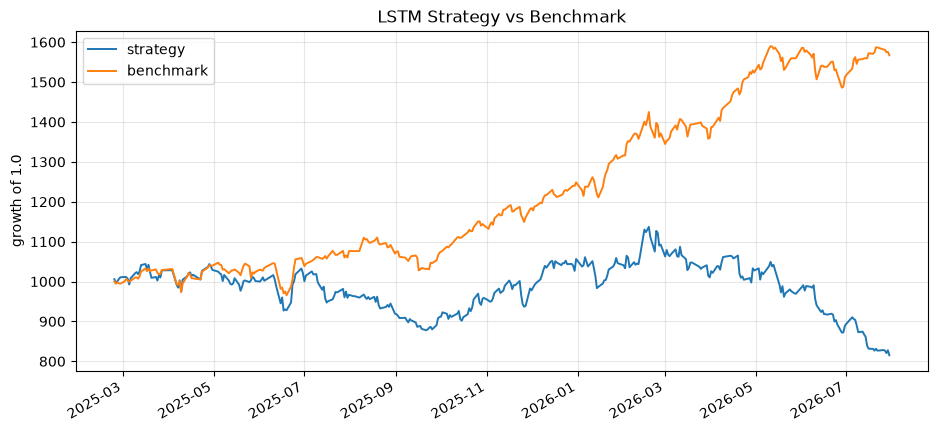

total return   : -18.5%
sharpe         : -0.55
max drawdown   : 28.3%
final value    : 815.08   (benchmark 1567.20)
beat benchmark : no
                 you lost to the benchmark by 752 EGP


In [64]:
from tradinglab.report import report

report(
    result_lstm,
    title="LSTM Strategy vs Benchmark",
    start_capital=1000.0
)

In [65]:
from tradinglab.models import MLP
from tradinglab.ml import train_model

torch.manual_seed(0)

mlp = MLP(
    n_features=n_features,
    hidden=32
)

mlp_history = train_model(
    mlp,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=1500
)

print(
    "MLP final train loss:",
    mlp_history["train"][-1]
)

print(
    "MLP final test loss:",
    mlp_history["test"][-1]
)

MLP final train loss: 0.0009403909789398313
MLP final test loss: 0.0005798909114673734


In [66]:
result_mlp = run_backtest(
    sim,
    model_to_strategy(
        mlp,
        top_k=TOP_K
    ),
    lookback=30,
    start=split
)

print("MLP backtest completed!")
print("Portfolio days:", len(result_mlp["portfolio"]))

MLP backtest completed!
Portfolio days: 347


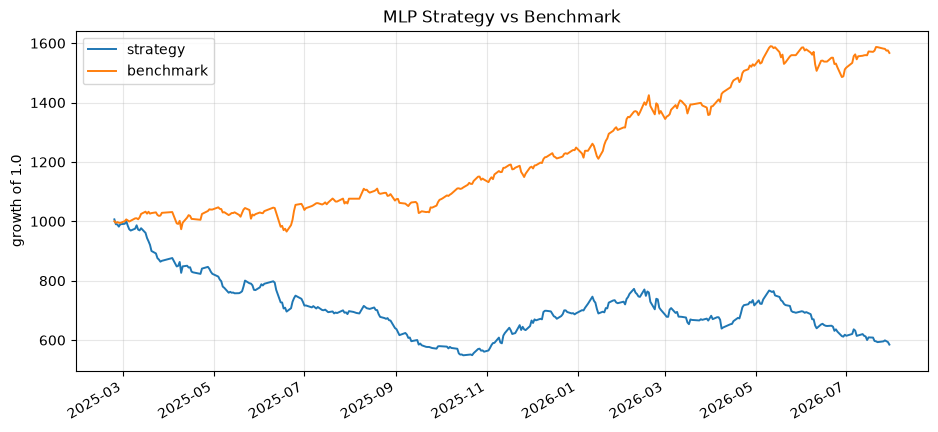

total return   : -41.5%
sharpe         : -1.49
max drawdown   : 45.5%
final value    : 584.96   (benchmark 1567.20)
beat benchmark : no
                 you lost to the benchmark by 982 EGP


In [67]:
from tradinglab.report import report

report(
    result_mlp,
    title="MLP Strategy vs Benchmark",
    start_capital=1000.0
)

In [68]:
print("========== MODEL COMPARISON ==========")

print(f"LSTM final value : {result_lstm['portfolio'][-1] * 1000:.2f} EGP")
print(f"MLP final value  : {result_mlp['portfolio'][-1] * 1000:.2f} EGP")

print()

print(f"LSTM total return: {(result_lstm['portfolio'][-1] - 1) * 100:+.2f}%")
print(f"MLP total return : {(result_mlp['portfolio'][-1] - 1) * 100:+.2f}%")

========== MODEL COMPARISON ==========
LSTM final value : 815.08 EGP
MLP final value  : 584.96 EGP

LSTM total return: -18.49%
MLP total return : -41.50%


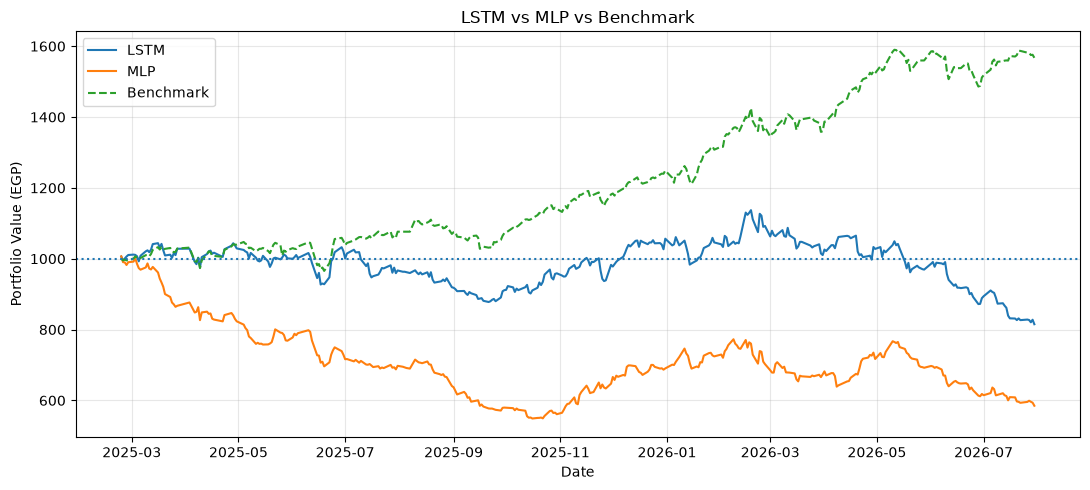

In [69]:
plt.figure(figsize=(11, 5))

plt.plot(
    result_lstm["dates"],
    result_lstm["portfolio"] * 1000,
    label="LSTM"
)

plt.plot(
    result_mlp["dates"],
    result_mlp["portfolio"] * 1000,
    label="MLP"
)

plt.plot(
    result_lstm["dates"],
    result_lstm["benchmark"] * 1000,
    label="Benchmark",
    linestyle="--"
)

plt.axhline(
    1000,
    linestyle=":"
)

plt.title("LSTM vs MLP vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (EGP)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
print("========== FINAL RESULTS ==========")

lstm_final = result_lstm["portfolio"][-1] * 1000
mlp_final = result_mlp["portfolio"][-1] * 1000
benchmark_final = result_lstm["benchmark"][-1] * 1000

lstm_return = (result_lstm["portfolio"][-1] - 1) * 100
mlp_return = (result_mlp["portfolio"][-1] - 1) * 100
benchmark_return = (result_lstm["benchmark"][-1] - 1) * 100

print(f"LSTM       : {lstm_final:.2f} EGP | Return: {lstm_return:+.2f}%")
print(f"MLP        : {mlp_final:.2f} EGP | Return: {mlp_return:+.2f}%")
print(f"Benchmark  : {benchmark_final:.2f} EGP | Return: {benchmark_return:+.2f}%")

print()

if mlp_final > lstm_final:
    print("Better model: MLP")
else:
    print("Better model: LSTM")

========== FINAL RESULTS ==========
LSTM       : 815.08 EGP | Return: -18.49%
MLP        : 584.96 EGP | Return: -41.50%
Benchmark  : 1567.20 EGP | Return: +56.72%

Better model: LSTM


In [71]:
# Diagnose whether the model has useful directional information

actual = np.asarray(y_test_seq).reshape(-1)
predicted = np.asarray(lstm_predictions).reshape(-1)

directional_accuracy = np.mean(
    np.sign(actual) == np.sign(predicted)
)

print("========== LSTM DIAGNOSTIC ==========")
print(f"Test MSE              : {np.mean((actual - predicted) ** 2):.6f}")
print(f"Test RMSE             : {np.sqrt(np.mean((actual - predicted) ** 2)):.6f}")
print(f"Directional Accuracy  : {directional_accuracy:.2%}")
print(f"Mean actual return    : {actual.mean():.6f}")
print(f"Mean predicted return : {predicted.mean():.6f}")
print(f"Min prediction        : {predicted.min():.6f}")
print(f"Max prediction        : {predicted.max():.6f}")

========== LSTM DIAGNOSTIC ==========
Test MSE              : 0.000578
Test RMSE             : 0.024046
Directional Accuracy  : 43.83%
Mean actual return    : 0.001343
Mean predicted return : 0.001929
Min prediction        : -0.000678
Max prediction        : 0.007408


In [72]:
print("========== PREDICTION DISTRIBUTION ==========")

print("Positive predictions:",
      np.sum(predicted > 0),
      "/",
      len(predicted))

print("Negative predictions:",
      np.sum(predicted < 0),
      "/",
      len(predicted))

print("Near-zero predictions:",
      np.sum(np.abs(predicted) < 0.0005),
      "/",
      len(predicted))

========== PREDICTION DISTRIBUTION ==========
Positive predictions: 11782 / 11788
Negative predictions: 6 / 11788
Near-zero predictions: 40 / 11788
